# 04 — Explainability (SHAP)

**Input:** `data/processed/xgb_best.pkl`, `X_test.parquet`, `y_proba.parquet`  
**Output:** SHAP plots saved to `reports/figures/`

RGPD (Article 22) requires that automated decisions affecting customers
be explainable on request. The waterfall plot produced here gives a
per-customer audit trail that satisfies this requirement.

Steps:
1. Global importance (bar + beeswarm)
2. Dependence plot for top feature
3. Per-customer waterfall (RGPD audit view)

In [2]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 9.9 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

plt.rcParams.update({'figure.dpi': 130})

with open('data/processed/xgb_best.pkl', 'rb') as f:
    artefacts = pickle.load(f)

model  = artefacts['model']
scaler = artefacts['scaler']

X_test  = pd.read_parquet('data/processed/X_test.parquet')
y_test  = pd.read_parquet('data/processed/y_test.parquet').squeeze()
y_proba = pd.read_parquet('data/processed/y_proba.parquet')['y_proba'].values

X_test_scaled    = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f'Test set: {len(X_test):,} customers')

Test set: 2,000 customers


## 1. Compute SHAP values

In [4]:
explainer = shap.TreeExplainer(model)
shap_vals = explainer(X_test_scaled_df)

shap_vals.feature_names = list(X_test.columns)

print(f'SHAP values computed — shape: {shap_vals.values.shape}')

SHAP values computed — shape: (2000, 14)


## 2. Global importance — bar chart

Mean absolute SHAP value per feature. Recommended hero image for the GitHub README and LinkedIn post.

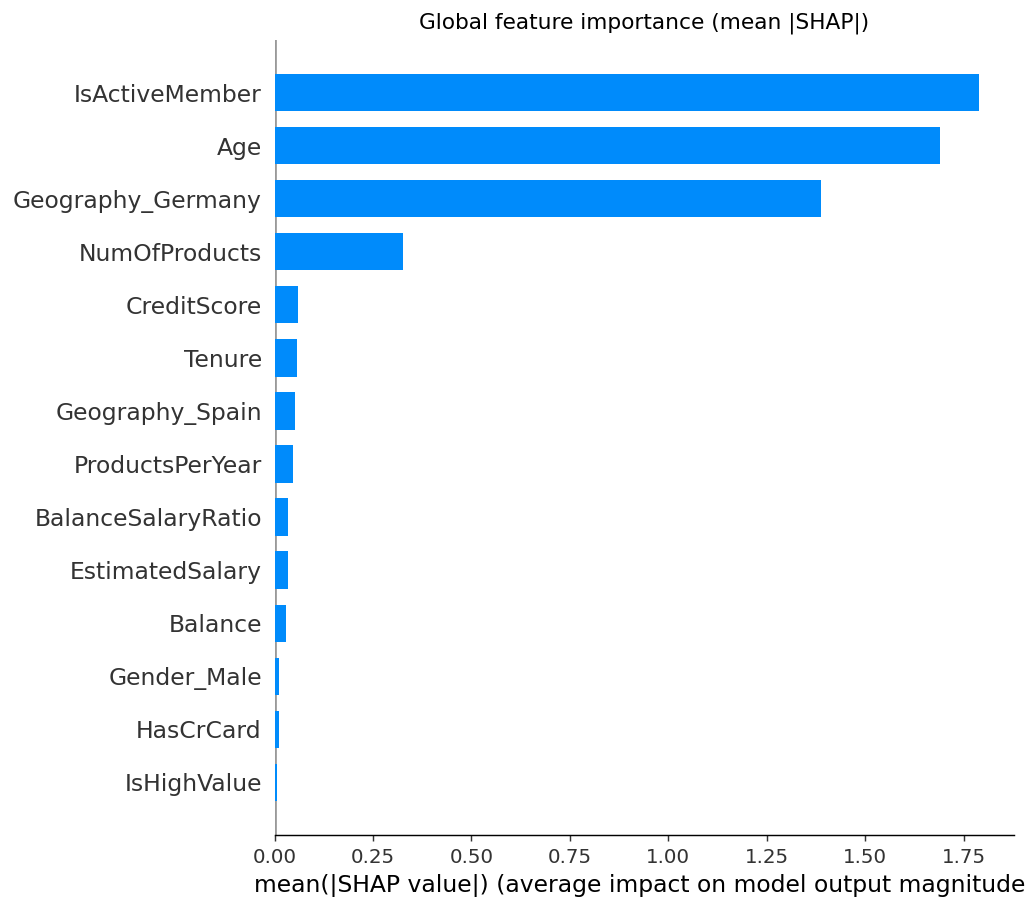

In [5]:
shap.summary_plot(shap_vals, X_test_scaled_df, plot_type='bar', show=False)
plt.title('Global feature importance (mean |SHAP|)')
plt.tight_layout()
plt.savefig('reports/figures/04_shap_bar.png', bbox_inches='tight')
plt.show()

## 3. Beeswarm plot

Shows both the magnitude and direction of each feature's effect.
Red = high feature value, blue = low feature value.

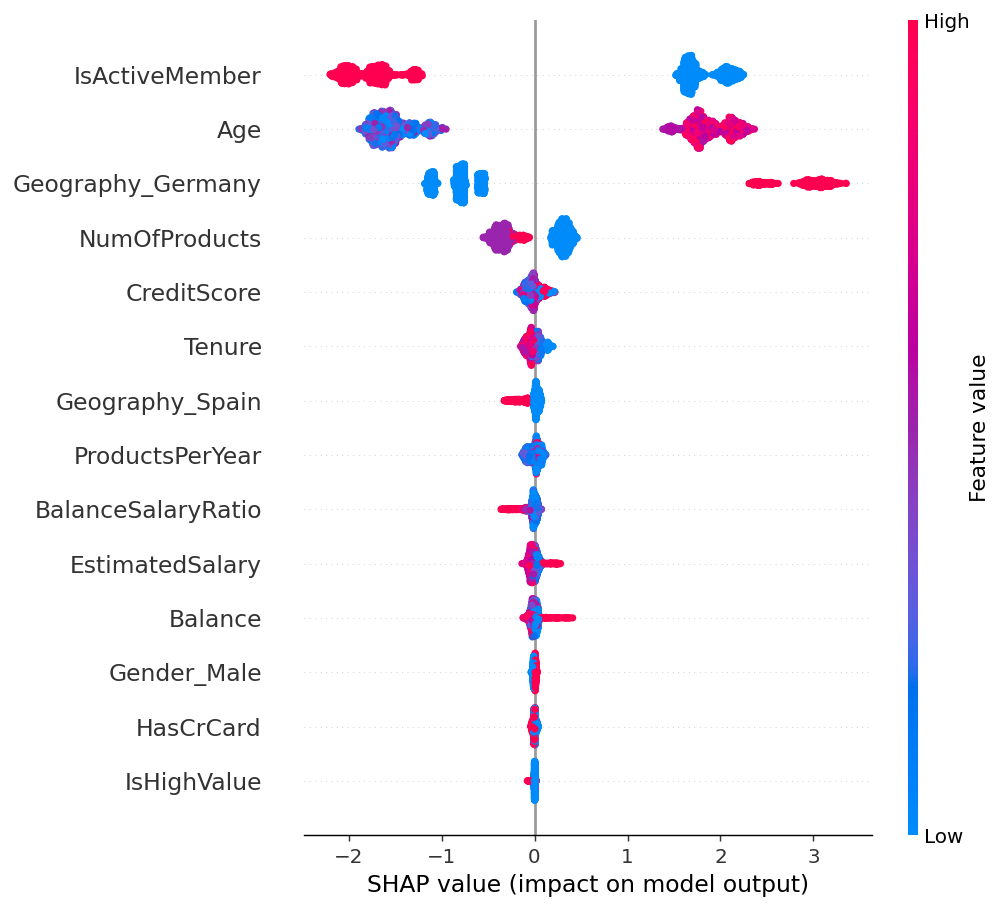

In [6]:
shap.summary_plot(shap_vals, X_test_scaled_df, show=False)
plt.tight_layout()
plt.savefig('reports/figures/04_shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 4. Dependence plot — Age

Shows how Age interacts with the strongest correlated feature to drive churn risk.
The colour axis is automatically chosen by SHAP.

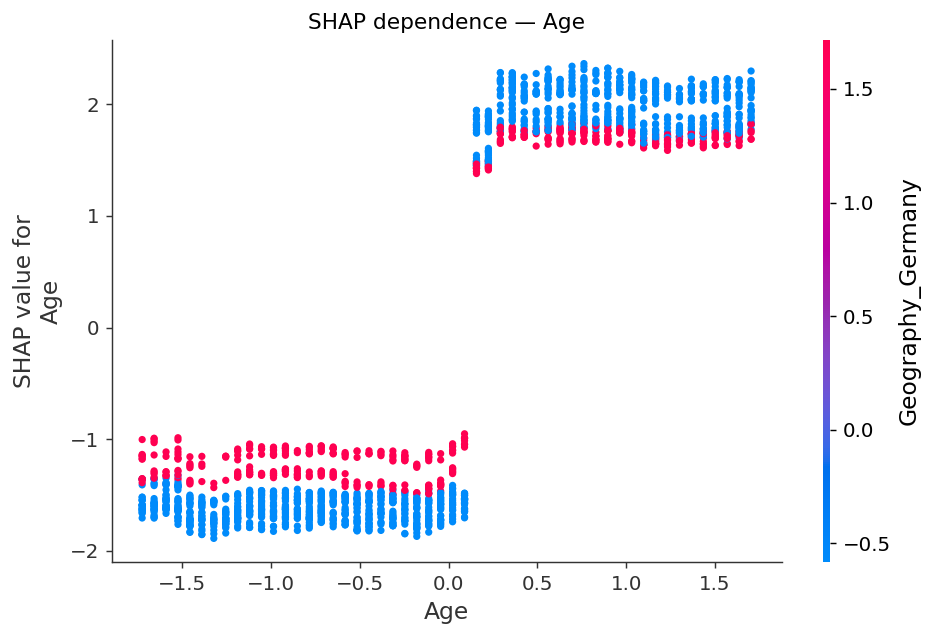

In [7]:
shap.dependence_plot(
    'Age', shap_vals.values, X_test_scaled_df,
    interaction_index='auto', show=False
)
plt.title('SHAP dependence — Age')
plt.tight_layout()
plt.savefig('reports/figures/04_shap_dependence_age.png', bbox_inches='tight')
plt.show()

## 5. Per-customer waterfall — RGPD audit view

Select the highest-risk customer in the test set and decompose
their predicted churn probability feature by feature.

In [8]:
highest_risk_idx = int(np.argmax(y_proba))

print(f'Customer index  : {highest_risk_idx}')
print(f'Predicted churn : {y_proba[highest_risk_idx]:.1%}')
print(f'Actual outcome  : {"Churned" if y_test.iloc[highest_risk_idx] == 1 else "Retained"}')
print()
print('Customer profile:')
print(X_test.iloc[highest_risk_idx].to_string())

Customer index  : 1580
Predicted churn : 99.9%
Actual outcome  : Churned

Customer profile:
CreditScore                     495
Age                              57
Tenure                            4
Balance               194266.999164
NumOfProducts                     1
HasCrCard                         0
IsActiveMember                    0
EstimatedSalary       125461.520202
BalanceSalaryRatio         1.548407
ProductsPerYear                 0.2
IsHighValue                       0
Geography_Germany              True
Geography_Spain               False
Gender_Male                   False


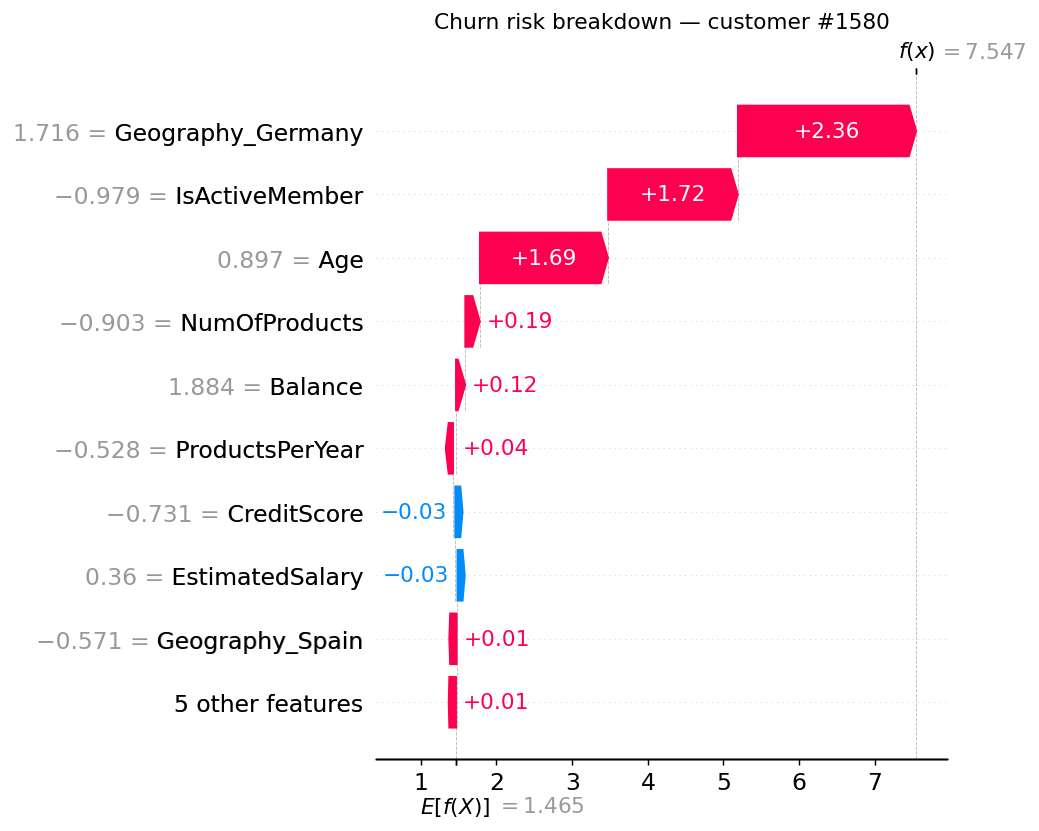

In [9]:
shap.plots.waterfall(shap_vals[highest_risk_idx], show=False)
plt.title(f'Churn risk breakdown — customer #{highest_risk_idx}')
plt.tight_layout()
plt.savefig(f'reports/figures/04_shap_waterfall_{highest_risk_idx}.png', bbox_inches='tight')
plt.show()

## 6. High-risk segment summary

Top 10 highest-risk customers with their primary churn driver.
This is what a retention team would act on in production.

In [10]:
top10_idx = np.argsort(y_proba)[-10:][::-1]

rows = []
for i in top10_idx:
    top_feat_idx = np.abs(shap_vals.values[i]).argmax()
    rows.append({
        'customer_idx': i,
        'churn_prob':   round(float(y_proba[i]), 3),
        'actual':       'Churned' if y_test.iloc[i] == 1 else 'Retained',
        'top_driver':   X_test.columns[top_feat_idx],
        'shap_value':   round(float(shap_vals.values[i, top_feat_idx]), 3),
    })

pd.DataFrame(rows)

,customer_idx,churn_prob,actual,top_driver,shap_value
0,1580,0.999,Churned,Geography_Germany,2.357
1,1400,0.999,Churned,Geography_Germany,2.340
2,893,0.999,Churned,Geography_Germany,2.365
3,1336,0.999,Churned,Geography_Germany,2.402
4,1545,0.999,Churned,Geography_Germany,2.308
5,1141,0.999,Churned,Geography_Germany,2.383
6,320,0.999,Churned,Geography_Germany,2.337
7,1421,0.999,Churned,Geography_Germany,2.359
8,867,0.999,Churned,Geography_Germany,2.361
9,353,0.999,Churned,Geography_Germany,2.360
